# Задача регрессии: предсказание стоимости недвижимости в Санкт-Петербурге

## Цель задачи: построить модель машинного обучения, которая по характеристикам квартиры (площадь, этаж, тип здания и т.д.) предсказывает её рыночную стоимость в рублях. Данные - объявления о продаже недвижимости по России за 2018-2021 годы.

## 1. Импорт библиотек
 
Подключаем все необходимые инструменты: `pandas` и `numpy` для работы с данными, `sklearn` для линейной модели и метрик, `category_encoders` для кодирования категориальных признаков, `xgboost` для градиентного бустинга и `matplotlib`/`seaborn` для визуализации.

In [1]:
# Импорт основных библиотек
import pandas as pd
import numpy as np

# Библиотека для машинного обучения
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

# Библиотека для кодирования категориальных признаков
import category_encoders as ce

# XGBoost
import xgboost as xgb

# Для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Загрузка датасета
 
Загружаем CSV-файл `all_v2.csv` и смотрим на его структуру: размер таблицы, названия колонок, первые строки.

In [2]:
# Загружаем датасет
df = pd.read_csv('all_v2.csv')

# Смотрим размер таблицы - сколько строк и столбцов
print("Размер датасета:", df.shape)

# Смотрим названия всех колонок
print("\nНазвания колонок:")
print(df.columns.tolist())

# Смотрим первые 5 строк чтобы понять как выглядят данные
df.head()

Размер датасета: (5477006, 13)

Названия колонок:
['price', 'date', 'time', 'geo_lat', 'geo_lon', 'region', 'building_type', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'object_type']


,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
1,8650000,2018-02-27,12:04:54,55.683807,37.297405,81,3,5,24,2,69.1,12.0,1
2,4000000,2018-02-28,15:44:00,56.295250,44.061637,2871,1,5,9,3,66.0,10.0,1
3,1850000,2018-03-01,11:24:52,44.996132,39.074783,2843,4,12,16,2,38.0,5.0,11
4,5450000,2018-03-01,17:42:43,55.918767,37.984642,81,3,13,14,2,60.0,10.0,1


Загрузили датасет - он содержит 5 477 006 строк и 13 колонок. Данные представляют собой объявления о продаже недвижимости по всей России за 2018-2021 годы. Видим колонки: цена, дата, координаты, регион, тип здания, этаж, этажность, число комнат, площади и тип объекта.

# 3. Фильтрация по региону
 
Оставляем только объявления из Санкт-Петербурга и области: фильтруем строки, где `region == 2661`.

In [3]:
# Фильтруем только Санкт-Петербург и область (код региона 2661)
df = df[df['region'] == 2661]

# Проверяем сколько строк осталось
print("Размер после фильтрации по региону:", df.shape)

# Смотрим первые строки
df.head()

Размер после фильтрации по региону: (461820, 13)


,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
7,3600000,2018-03-04,20:52:38,59.875526,30.395457,2661,1,2,5,1,31.1,6.0,1
36,3200000,2018-04-10,16:10:12,59.827465,30.201827,2661,1,7,9,1,31.0,7.0,1
47,6500000,2018-04-23,11:47:58,59.988334,29.786928,2661,3,3,3,3,89.0,10.0,1
54,6300000,2018-04-28,17:47:24,59.911622,30.284556,2661,3,5,5,2,99.9,14.5,1


Отфильтровали датасет по региону 2661 (Санкт-Петербург и область). Из 5 477 006 строк осталось 461 820 объявлений - это наша рабочая выборка для дальнейшей работы.

# 4. Фильтрация типовых объектов
 
Убираем нетипичные объекты по трём условиям:
 
- Общая площадь (`area`): от 20 до 200 кв. м.
- Площадь кухни (`kitchen_area`): от 6 до 30 кв. м.
- Цена (`price`): от 1,5 млн до 50 млн рублей

In [4]:
# Оставляем только типовые объекты по трём условиям
df = df[
    (df['area'] >= 20) & (df['area'] <= 200) &
    (df['kitchen_area'] >= 6) & (df['kitchen_area'] <= 30) &
    (df['price'] >= 1_500_000) & (df['price'] <= 50_000_000)
]

# Проверяем сколько строк осталось
print("Размер после фильтрации типовых объектов:", df.shape)

df.head()

Размер после фильтрации типовых объектов: (410663, 13)


,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
7,3600000,2018-03-04,20:52:38,59.875526,30.395457,2661,1,2,5,1,31.1,6.0,1
36,3200000,2018-04-10,16:10:12,59.827465,30.201827,2661,1,7,9,1,31.0,7.0,1
47,6500000,2018-04-23,11:47:58,59.988334,29.786928,2661,3,3,3,3,89.0,10.0,1
54,6300000,2018-04-28,17:47:24,59.911622,30.284556,2661,3,5,5,2,99.9,14.5,1


Отфильтровали нетипичные объекты по площади, площади кухни и цене. Из 461 820 строк осталось 410 663 объявления - убрали около 50 тысяч выбросов (слишком дорогие, огромные или нестандартные квартиры).

## 5. Исправление значений в колонке rooms
 
Заменяем значения `-1` и `-2` в колонке `rooms` на `0`.
Значения `-1` и `-2` обозначают студии и свободные планировки (без отдельных комнат). Это не ошибки, а особый тип жилья. Заменяем их на `0`, чтобы модель понимала: ноль комнат = студия.

In [5]:
# Смотрим какие уникальные значения есть в колонке rooms ДО замены
print("Уникальные значения rooms ДО замены:")
print(sorted(df['rooms'].unique()))

# Заменяем -1 и -2 на 0
df['rooms'] = df['rooms'].replace({-1: 0, -2: 0})

# Проверяем что получилось ПОСЛЕ замены
print("\nУникальные значения rooms ПОСЛЕ замены:")
print(sorted(df['rooms'].unique()))

Уникальные значения rooms ДО замены:
[np.int64(-2), np.int64(-1), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Уникальные значения rooms ПОСЛЕ замены:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


Теперь значения комнат идут от 0 до 9, что логично и корректно.

## 6. Создание новых признаков
 
Добавляем четыре новых признака:
 
- `floor_ratio` - доля этажа квартиры от этажности дома (`level / levels`)
- `is_first` - находится ли квартира на первом этаже (1 или 0)
- `is_last` - находится ли квартира на последнем этаже (1 или 0)
- `ratio` - отношение площади кухни к общей площади; если квартира-студия (`rooms == 0`), то берётся просто общая площадь

In [6]:
# Отношение этажа квартиры к этажности дома
df['floor_ratio'] = df['level'] / df['levels']

# Первый этаж - да или нет (1 или 0)
df['is_first'] = (df['level'] == 1).astype(int)

# Последний этаж - да или нет (1 или 0)
df['is_last'] = (df['level'] == df['levels']).astype(int)

# Отношение площади кухни к общей площади
# Если студия (rooms == 0) - берём просто общую площадь
df['ratio'] = df.apply(
    lambda row: row['area'] if row['rooms'] == 0 else row['kitchen_area'] / row['area'],
    axis=1
)

# Проверяем что получилось
print("Новые признаки добавлены!")
print(df[['level', 'levels', 'floor_ratio', 'is_first', 'is_last', 'rooms', 'area', 'kitchen_area', 'ratio']].head(10))

Новые признаки добавлены!
     level  levels  floor_ratio  is_first  is_last  rooms  area  kitchen_area  \
0        8      10     0.800000         0        0      3  82.6          10.8   
7        2       5     0.400000         0        0      1  31.1           6.0   
36       7       9     0.777778         0        0      1  31.0           7.0   
47       3       3     1.000000         0        1      3  89.0          10.0   
54       5       5     1.000000         0        1      2  99.9          14.5   
66       7      12     0.583333         0        0      3  69.0          11.0   
69      14      14     1.000000         0        1      2  60.0          11.0   
76       2      17     0.117647         0        0      1  44.9          16.5   
98       3       4     0.750000         0        0      2  52.6           8.8   
106      1       6     0.166667         1        0      3  68.0           8.3   

        ratio  
0    0.130751  
7    0.192926  
36   0.225806  
47   0.112360  
54

Добавлены 4 новых признака. Все значения логичны — например, квартира на этаже 3 из 3 даёт `is_last = 1` и `floor_ratio = 1.0`.

## 7. Добавление признака «давность объявления» (days_old)
 
Вычисляем сколько дней прошло от даты публикации объявления до максимальной даты в датасете.
 
Для этого переводим колонку `date` в формат datetime, находим `max_date`, считаем разницу в днях.
 
Это необходимо, так как цены на недвижимость меняются со временем. Более старые объявления отражают другой уровень цен. Давность объявления позволяет модели учесть временной фактор.

In [7]:
# Переводим колонку date из текста в формат даты
df['date'] = pd.to_datetime(df['date'])

# Смотрим какой диапазон дат у нас есть
print("Минимальная дата:", df['date'].min())
print("Максимальная дата:", df['date'].max())

# В качестве даты отсчёта берём максимальную дату в датасете
max_date = df['date'].max()

# Считаем давность объявления в днях
df['days_old'] = (max_date - df['date']).dt.days

# Проверяем что получилось
print("\nПример признака days_old:")
print(df[['date', 'days_old']].head(10))

Минимальная дата: 2018-02-19 00:00:00
Максимальная дата: 2021-05-01 00:00:00

Пример признака days_old:
          date  days_old
0   2018-02-19      1167
7   2018-03-04      1154
36  2018-04-10      1117
47  2018-04-23      1104
54  2018-04-28      1099
66  2018-05-22      1075
69  2018-05-26      1071
76  2018-06-02      1064
98  2018-06-29      1037
106 2018-07-04      1032


Добавили признак `days_old` - давность объявления в днях относительно максимальной даты в датасете (01.05.2021). 

Датасет охватывает период с февраля 2018 по май 2021. Самые старые объявления имеют давность около 1167 дней.

## 8. Матрица корреляции
 
Строим тепловую карту корреляций между всеми числовыми признаками.
 
Для этого мы отбираем числовые колонки, вычисляем `.corr()`, визуализируем через `sns.heatmap`. Отдельно выводим корреляцию каждого признака с `price`.
 
Матрица корреляции показывает, какие признаки наиболее линейно связаны с целевой переменной, и помогает выявить признаки, которые дублируют информацию друг друга (мультиколлинеарность).

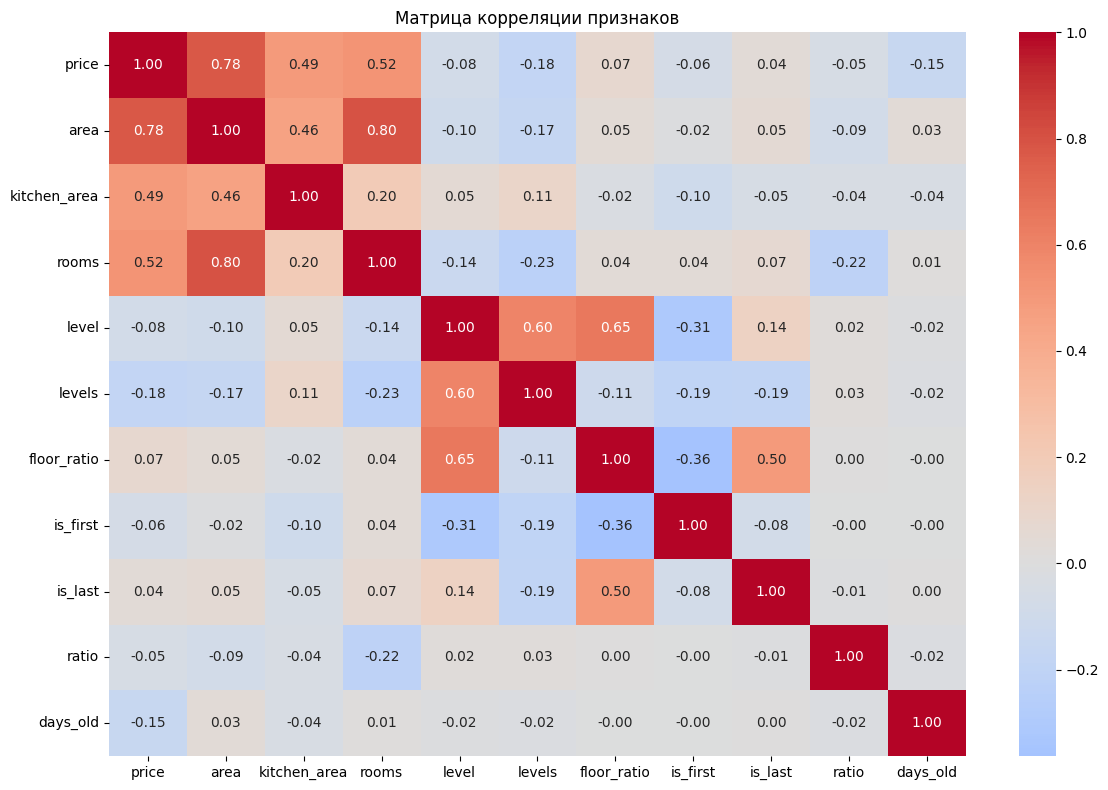


Корреляция признаков с ценой (price):
price           1.000000
area            0.780188
rooms           0.524654
kitchen_area    0.490240
floor_ratio     0.073884
is_last         0.037881
ratio          -0.051590
is_first       -0.060652
level          -0.076799
days_old       -0.146865
levels         -0.177535
Name: price, dtype: float64


In [8]:
# Выбираем только числовые колонки для матрицы корреляции
numeric_cols = ['price', 'area', 'kitchen_area', 'rooms', 'level', 
                'levels', 'floor_ratio', 'is_first', 'is_last', 
                'ratio', 'days_old']

# Строим матрицу корреляции
corr_matrix = df[numeric_cols].corr()

# Визуализируем в виде тепловой карты
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,        # показывать числа внутри
    fmt='.2f',         # округлять до 2 знаков
    cmap='coolwarm',   # цветовая схема
    center=0           # белый цвет = нет корреляции
)
plt.title('Матрица корреляции признаков')
plt.tight_layout()
plt.show()

# Смотрим корреляцию именно с ценой - от большей к меньшей
print("\nКорреляция признаков с ценой (price):")
print(corr_matrix['price'].sort_values(ascending=False))

Наиболее сильно с ценой коррелируют `area` (0.78), `rooms` (0.52) и `kitchen_area` (0.49) - чем больше квартира, тем она дороже. Признак `days_old` имеет слабую отрицательную корреляцию (-0.15): более старые объявления чуть дешевле.

## 9. Кодирование категориальных признаков
 
Переводим `building_type` (тип здания) и `object_type` (тип объекта) из категорий в числовые признаки с помощью Binary Encoder.

In [9]:
# Смотрим уникальные значения категориальных признаков
print("Уникальные значения building_type:", df['building_type'].unique())
print("Уникальные значения object_type:", df['object_type'].unique())

# Переводим в строковый тип чтобы энкодер работал корректно
df['building_type'] = df['building_type'].astype(str)
df['object_type'] = df['object_type'].astype(str)

# Применяем Binary Encoder
encoder = ce.BinaryEncoder(cols=['building_type', 'object_type'])
df_encoded = encoder.fit_transform(df)

# Смотрим что получилось
print("\nРазмер после кодирования:", df_encoded.shape)
print("\nНовые колонки после кодирования:")
print(df_encoded.columns.tolist())

Уникальные значения building_type: [1 3 2 4 0 5]
Уникальные значения object_type: [ 1 11]

Размер после кодирования: (410663, 21)

Новые колонки после кодирования:
['price', 'date', 'time', 'geo_lat', 'geo_lon', 'region', 'building_type_0', 'building_type_1', 'building_type_2', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'object_type_0', 'object_type_1', 'floor_ratio', 'is_first', 'is_last', 'ratio', 'days_old']


Вместо двух исходных колонок появились бинарные: `building_type_0`, `building_type_1`, `building_type_2` и `object_type_0`, `object_type_1`. 

Датасет вырос с 13 до 21 колонки.

## 10. Подготовка признаков и разбивка на выборки

Определяем финальный набор признаков и делим данные на обучающую и тестовую выборки.
 
Формируем список `feature_cols` из 15 признаков (убираем `price`, `date`, `time`, `region` и координаты), разбиваем через `train_test_split` в пропорции 80/20 с `random_state=42`.

In [10]:
# Определяем какие колонки будем использовать как признаки (X)
# Убираем ненужные: цену (это наша цель), дату, время, регион (он один - 2661)
feature_cols = [
    'area', 'kitchen_area', 'rooms', 'level', 'levels',
    'building_type_0', 'building_type_1', 'building_type_2',
    'object_type_0', 'object_type_1',
    'floor_ratio', 'is_first', 'is_last', 'ratio', 'days_old'
]

# X - признаки, y - целевая переменная (цена)
X = df_encoded[feature_cols]
y = df_encoded['price']

print("Размер X (признаки):", X.shape)
print("Размер y (цена):", y.shape)

# Разбиваем на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% на тест
    random_state=42     # фиксируем случайность для воспроизводимости
)

print("\nРазмер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер X (признаки): (410663, 15)
Размер y (цена): (410663,)

Размер обучающей выборки: (328530, 15)
Размер тестовой выборки: (82133, 15)


Матрица признаков `X` - 15 колонок, целевая переменная `y` - цена. Обучающая выборка: 328 530 объектов, тестовая: 82 133 объекта.

## 11. Стандартизация и обучение модели Ridge
 
Масштабируем признаки и обучаем линейную модель с L2-регуляризацией.
 
Создаём `StandardScaler`, применяем `fit_transform` к тренировочным данным и только `transform` к тестовым. Обучаем `Ridge(alpha=1.0)`.

Линейная регрессия чувствительна к масштабу признаков - площадь в сотнях квадратных метров будет «перевешивать» бинарный признак `is_first`. Стандартизация приводит все признаки к одному масштабу. 

Важно: стандартизатор обучается только на тренировочной выборке, иначе модель «подсмотрит» статистику тестовых данных.

In [12]:
# Создаём стандартизатор
scaler = StandardScaler()

# Обучаем стандартизатор на обучающей выборке и применяем к ней
X_train_scaled = scaler.fit_transform(X_train)

# К тестовой выборке только применяем (не обучаем заново!)
X_test_scaled = scaler.transform(X_test)

# Создаём и обучаем модель Ridge (линейная регрессия с L2-регуляризацией)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Делаем предсказания
y_pred_train_ridge = ridge_model.predict(X_train_scaled)
y_pred_test_ridge = ridge_model.predict(X_test_scaled)

## 12. Обучение модели XGBoost
 
Обучаем модель градиентного бустинга на тех же данных.
 
Обучаем на сырых (нестандартизованных) данных. Деревья решений устойчивы к масштабу признаков и не требуют стандартизации. XGBoost умеет улавливать нелинейные зависимости, которые линейная регрессия упускает, что потенциально даёт лучшее качество.

In [13]:
# Создаём и обучаем модель XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=200,     # количество деревьев
    learning_rate=0.1,    # скорость обучения
    max_depth=6,          # максимальная глубина дерева
    random_state=42,
    verbosity=1           # показывать прогресс обучения
)

xgb_model.fit(X_train, y_train)

# Делаем предсказания
y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_test_xgb = xgb_model.predict(X_test)

## 13. Метрики качества моделей
 
Оцениваем качество обеих моделей на обучающей и тестовой выборках.
 
Считаем три метрики - `RMSE` (корень из среднеквадратичной ошибки, в рублях), `MAE` (средняя абсолютная ошибка, в рублях), `R²` (коэффициент детерминации). 

Для каждой модели считаем метрики и на train, и на test. Одной метрики недостаточно. RMSE сильнее штрафует за большие ошибки, MAE более устойчива к выбросам. R² показывает, какую долю дисперсии цен объясняет модель. Сравнение train vs test позволяет выявить переобучение.

In [14]:
import numpy as np

def print_metrics(y_true, y_pred, model_name, sample_name):
    rmse = np.sqrt(metrics.mean_squared_error(y_true, y_pred))
    mae = metrics.mean_absolute_error(y_true, y_pred)
    r2 = metrics.r2_score(y_true, y_pred)
    print(f"[{model_name}] {sample_name}:")
    print(f"  RMSE = {rmse:,.0f} руб.")
    print(f"  MAE  = {mae:,.0f} руб.")
    print(f"  R²   = {r2:.4f}")
    print()

# Метрики Ridge
print_metrics(y_train, y_pred_train_ridge, "Ridge", "Обучающая выборка")
print_metrics(y_test,  y_pred_test_ridge,  "Ridge", "Тестовая выборка")

# Метрики XGBoost
print_metrics(y_train, y_pred_train_xgb, "XGBoost", "Обучающая выборка")
print_metrics(y_test,  y_pred_test_xgb,  "XGBoost", "Тестовая выборка")

[Ridge] Обучающая выборка:
  RMSE = 2,818,360 руб.
  MAE  = 1,699,290 руб.
  R²   = 0.6908

[Ridge] Тестовая выборка:
  RMSE = 2,843,966 руб.
  MAE  = 1,716,207 руб.
  R²   = 0.6896

[XGBoost] Обучающая выборка:
  RMSE = 2,081,710 руб.
  MAE  = 1,224,145 руб.
  R²   = 0.8313

[XGBoost] Тестовая выборка:
  RMSE = 2,174,700 руб.
  MAE  = 1,259,358 руб.
  R²   = 0.8185



XGBoost значительно превосходит Ridge - R² = 0.82 против 0.69 на тестовой выборке, RMSE меньше почти на 700 тысяч рублей. Обе модели не переобучены: метрики на обучающей и тестовой выборках близки.

## 14. Анализ важности признаков (XGBoost)
 
Смотрим, какие признаки модель XGBoost считает наиболее значимыми.
 
Важность признаков помогает понять логику модели и выявить потенциальные проблемы, например утечку данных.

Важность признаков (от наиболее к наименее значимым):
area               0.587351
days_old           0.065898
levels             0.064886
building_type_2    0.053183
building_type_1    0.040630
rooms              0.039162
building_type_0    0.037721
kitchen_area       0.030039
object_type_0      0.022974
floor_ratio        0.018304
level              0.017457
is_last            0.012014
ratio              0.010380
object_type_1      0.000000
is_first           0.000000
dtype: float32


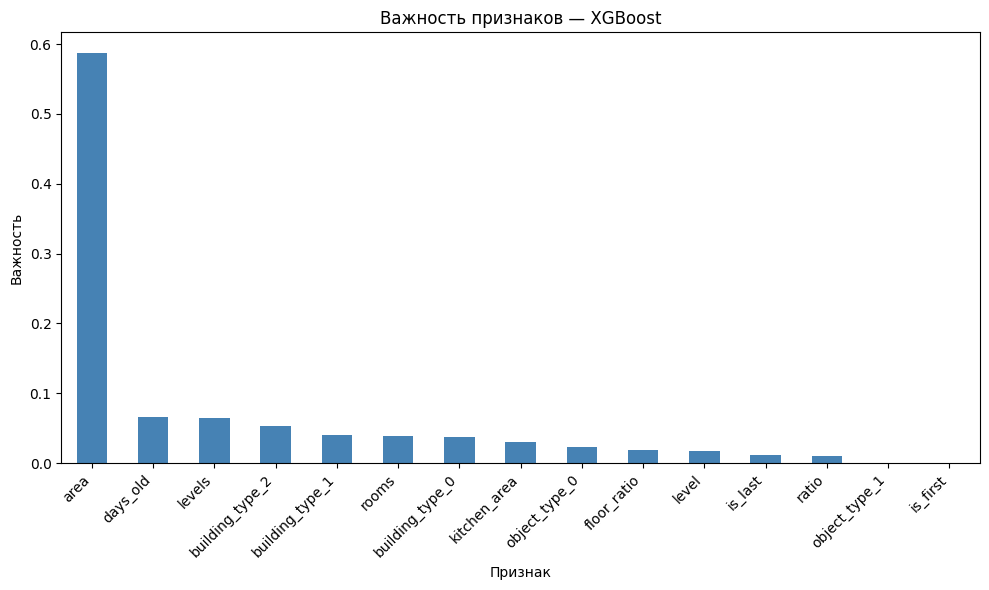

In [15]:
# Получаем важность признаков
feature_importances = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("Важность признаков (от наиболее к наименее значимым):")
print(feature_importances)

# Визуализируем
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar', color='steelblue')
plt.title('Важность признаков — XGBoost')
plt.ylabel('Важность')
plt.xlabel('Признак')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Самый важный признак - `area` (0.59), что логично. На втором месте оказался `days_old` (0.07).
 
Проблема с признаком `days_old` заключается в том, что 2018 по 2021 год цены в Санкт-Петербурге стабильно росли, поэтому старые объявления (большой `days_old`) в среднем дешевле. Модель уловила этот временной тренд. Однако при скоринге новой квартиры `days_old` будет равен 0, и модель окажется в ситуации, которой не видела при обучении. По сути, модель путает рыночный рост цен с реальными характеристиками квартиры. 

Как вариант решения: заменить давность объявления на индекс цен на недвижимость за соответствующий период.

## 15. Скоринг реальной квартиры
 
Подставляем характеристики конкретной квартиры и получаем предсказанную стоимость.
 
Вручную задаем параметры квартиры (2 комнаты, 45.3 кв.м., кухня 6.9 кв.м., 1 этаж из 9, панельный дом, Санкт-Петербург), применяем тот же `encoder` и `scaler`, делаем предсказание обеими моделями.

In [20]:
# Создаём строку с теми же колонками что были в df при обучении энкодера
my_apartment = pd.DataFrame({
    'price': [0],
    'date': ['2021-05-01'],        # макс дата датасета
    'time': ['00:00:00'],
    'geo_lat': [59.9],
    'geo_lon': [30.3],
    'region': [2661],
    'building_type': ['1'],        # панель = 1
    'level': [6],
    'levels': [9],
    'rooms': [4],
    'area': [75],
    'kitchen_area': [5],
    'object_type': ['1'],          # обычная квартира = 1
    'floor_ratio': [6/9],
    'is_first': [0],
    'is_last': [0],
    'ratio': [5/75],
    'days_old': [0],
})

# Кодируем категориальные признаки тем же энкодером
my_apartment_encoded = encoder.transform(my_apartment)

# Оставляем только нужные колонки в правильном порядке
my_apartment_encoded = my_apartment_encoded[feature_cols]

# Предсказание Ridge
my_price_ridge = ridge_model.predict(scaler.transform(my_apartment_encoded))

# Предсказание XGBoost
my_price_xgb = xgb_model.predict(my_apartment_encoded)

print("Оценка стоимости нашей квартиры:")
print(f"Ridge:   {my_price_ridge[0]:,.0f} руб.")
print(f"XGBoost: {my_price_xgb[0]:,.0f} руб.")

Оценка стоимости нашей квартиры:
Ridge:   8,739,369 руб.
XGBoost: 11,282,436 руб.


Произвели скоринг реальной квартиры.